In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

c:\Users\suvam.ray\miniconda3\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
load_dotenv()

model = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [7]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()


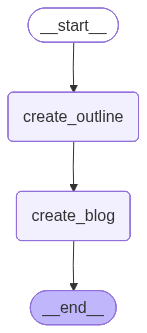

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [8]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'Here\'s a detailed outline for a blog on the topic "Rise of AI in India":\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Importance of AI in India\'s economic growth and development\n* Thesis statement: India is experiencing a significant rise in AI adoption, driven by government initiatives, technological advancements, and a growing talent pool.\n\n**II. Current State of AI in India**\n\n* Overview of India\'s AI landscape, including key industries and sectors where AI is being adopted (e.g., healthcare, finance, manufacturing)\n* Statistics on AI adoption in India, such as the number of AI startups, funding, and job creation\n* Discussion of the challenges and limitations of AI adoption in India, such as data quality, infrastructure, and skill gaps\n\n**III. Government Initiatives and Policies**\n\n* Overview of the Indian government\'s initiatives to promote AI adoption, s

In [9]:
print(final_state['outline'])

Here's a detailed outline for a blog on the topic "Rise of AI in India":

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its growing importance globally
* Importance of AI in India's economic growth and development
* Thesis statement: India is experiencing a significant rise in AI adoption, driven by government initiatives, technological advancements, and a growing talent pool.

**II. Current State of AI in India**

* Overview of India's AI landscape, including key industries and sectors where AI is being adopted (e.g., healthcare, finance, manufacturing)
* Statistics on AI adoption in India, such as the number of AI startups, funding, and job creation
* Discussion of the challenges and limitations of AI adoption in India, such as data quality, infrastructure, and skill gaps

**III. Government Initiatives and Policies**

* Overview of the Indian government's initiatives to promote AI adoption, such as:
	+ National AI Strategy
	+ AI Task Force
	+ NITI Aayog's 

In [10]:
print(final_state['content'])

**The Rise of AI in India: A New Era of Growth and Innovation**

**Introduction**

Artificial Intelligence (AI) has become a buzzword in the global economy, with its applications and potential uses expanding exponentially. As a rapidly growing economy, India is no exception to this trend. AI has the potential to revolutionize various industries and sectors in India, driving economic growth, and improving the quality of life for its citizens. With the Indian government's commitment to promoting AI adoption, technological advancements, and a growing talent pool, India is experiencing a significant rise in AI adoption. In this blog, we will explore the current state of AI in India, government initiatives, technological advancements, and the applications and use cases of AI in various industries.

**Current State of AI in India**

India's AI landscape is rapidly evolving, with key industries and sectors such as healthcare, finance, and manufacturing adopting AI technologies. The number of 